In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

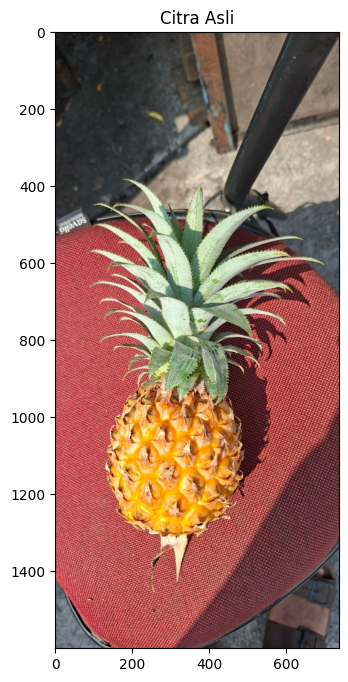

Ukuran citra: (1600, 737, 3)


In [23]:
img_bgr = cv2.imread("./img/nanas.jpeg")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(5, 8))
plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.show()

print("Ukuran citra:", img_bgr.shape)


In [ ]:
def buat_mask(hsv_img, lower, upper, kernel_size=7, open_iter=2, close_iter=3,
              area_ratio_threshold=0.05, keep_top_n=None):
    
    lower = np.array(lower)
    upper = np.array(upper)

    mask = cv2.inRange(hsv_img, lower, upper)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=open_iter)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=close_iter)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return mask

    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    largest_area = cv2.contourArea(contours[0])

    if keep_top_n is not None:
        selected = contours[:keep_top_n]
    else:
        selected = [c for c in contours if cv2.contourArea(c) >= area_ratio_threshold * largest_area]

    mask_bersih = np.zeros_like(mask)
    cv2.drawContours(mask_bersih, selected, -1, 255, thickness=cv2.FILLED)
    return mask_bersih


def segmentasi(img_rgb, mask):
    hasil = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    return hasil


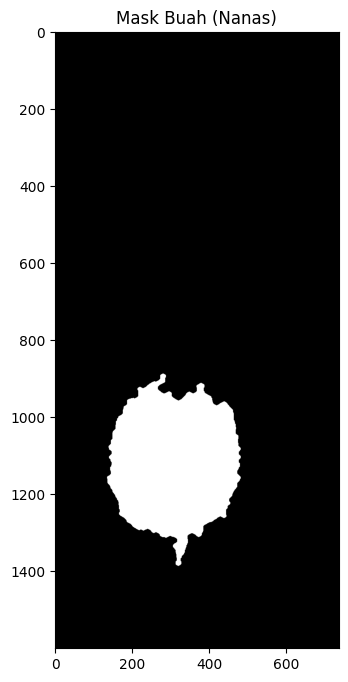

In [21]:
# Rentang HSV untuk buah nanas (sesuaikan dengan gambar sendiri bila perlu)
lower_buah = [8, 60, 100]
upper_buah = [27, 255, 255]

mask_buah = buat_mask(img_hsv, lower_buah, upper_buah, keep_top_n=1)

plt.figure(figsize=(5, 8))
plt.imshow(mask_buah, cmap="gray")
plt.title("Mask Buah (Nanas)")
plt.show()


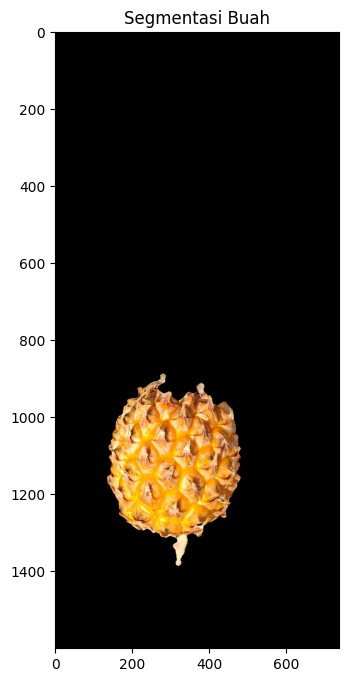

In [20]:
seg_buah = segmentasi(img_rgb, mask_buah)

plt.figure(figsize=(5, 8))
plt.imshow(seg_buah)
plt.title("Segmentasi Buah")
plt.show()


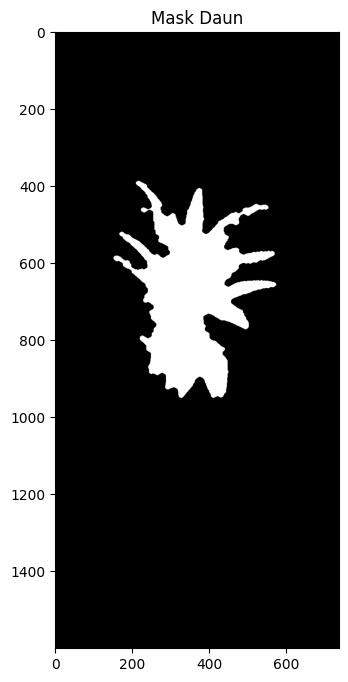

In [16]:
# Rentang HSV untuk daun nanas (sesuaikan dengan gambar sendiri bila perlu)
lower_daun = [30, 25, 40]
upper_daun = [80, 255, 255]

mask_daun = buat_mask(img_hsv, lower_daun, upper_daun, area_ratio_threshold=0.05)

plt.figure(figsize=(5, 8))
plt.imshow(mask_daun, cmap="gray")
plt.title("Mask Daun")
plt.show()


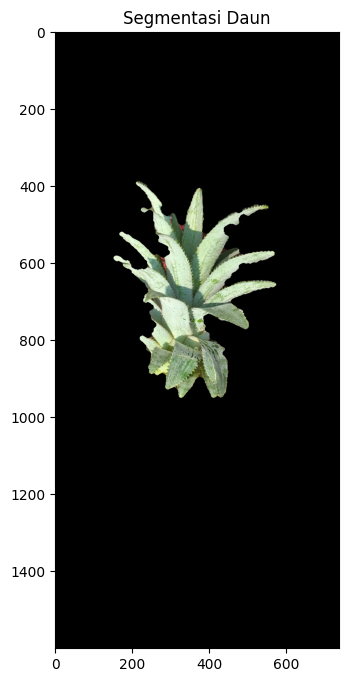

In [17]:
seg_daun = segmentasi(img_rgb, mask_daun)

plt.figure(figsize=(5, 8))
plt.imshow(seg_daun)
plt.title("Segmentasi Daun")
plt.show()


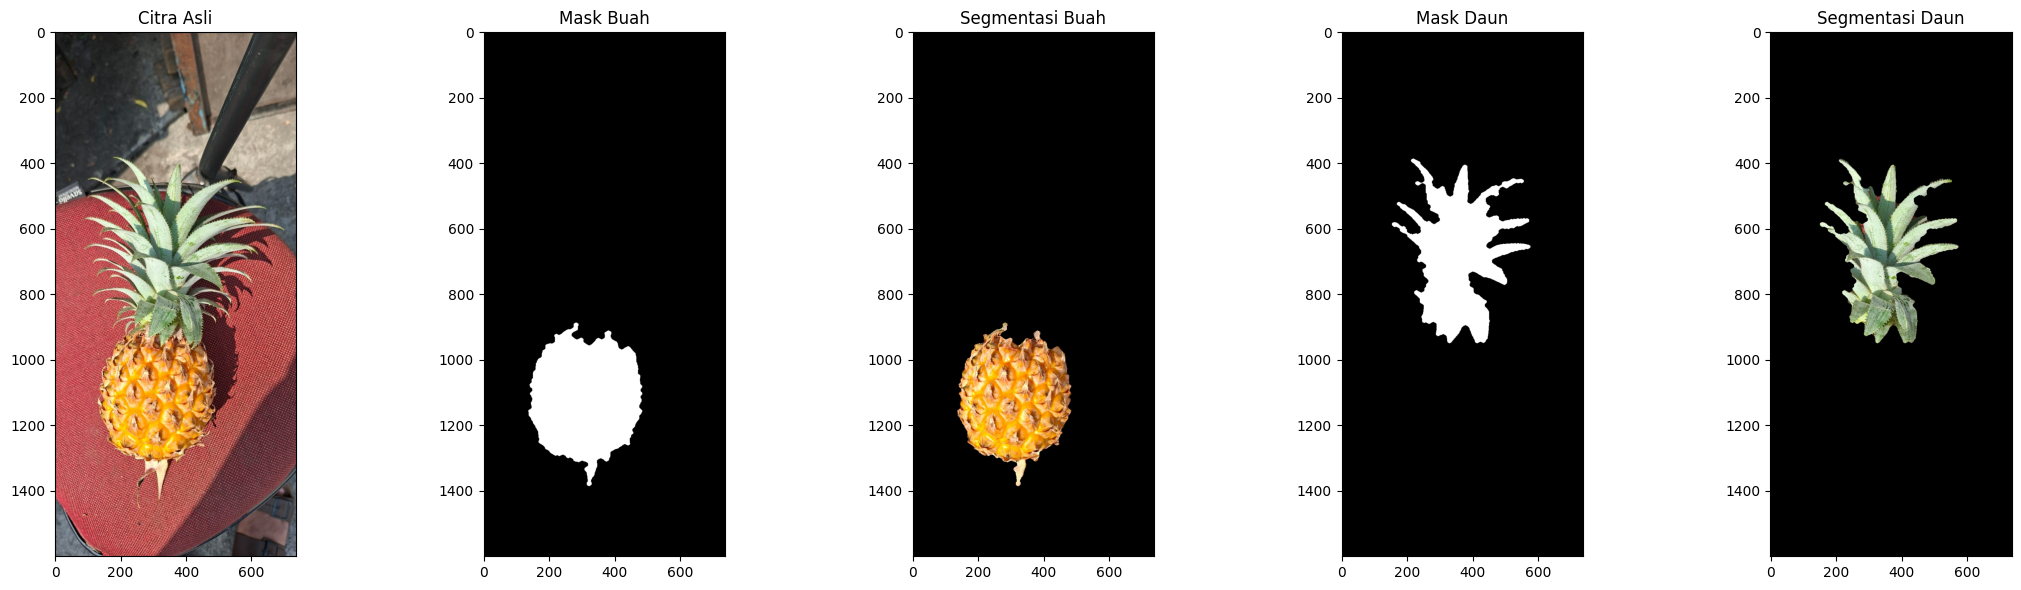

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

tampilan = [
    (img_rgb, "Citra Asli", None),
    (mask_buah, "Mask Buah", "gray"),
    (seg_buah, "Segmentasi Buah", None),
    (mask_daun, "Mask Daun", "gray"),
    (seg_daun, "Segmentasi Daun", None),
]

for ax, (gambar, judul, cmap) in zip(axes, tampilan):
    ax.imshow(gambar, cmap=cmap)
    ax.set_title(judul)

plt.tight_layout()
plt.savefig("hasil_deteksi_daun.png", dpi=150, bbox_inches="tight")
plt.show()


In [24]:
cv2.imwrite("./results/output_1_citra_asli.png", img_bgr)
cv2.imwrite("./results/output_2_mask_buah.png", mask_buah)
cv2.imwrite("./results/output_3_segmentasi_buah.png", cv2.cvtColor(seg_buah, cv2.COLOR_RGB2BGR))
cv2.imwrite("./results/output_4_mask_daun.png", mask_daun)
cv2.imwrite("./results/output_5_segmentasi_daun.png", cv2.cvtColor(seg_daun, cv2.COLOR_RGB2BGR))

print("Semua output berhasil disimpan.")

Semua output berhasil disimpan.
